# Ensemble and Deep Learning Comparison
# AI4I 2020 Predictive Maintenance

## Objective
Compare individual classifiers, ensemble strategies, and deep learning models to determine
the best approach for machine failure prediction under class imbalance.

Models compared:
- Logistic Regression (linear baseline)
- Random Forest (bagging)
- Gradient Boosting (boosting)
- XGBoost (optimized boosting)
- MLP (feedforward neural network)
- TabNet (attention based deep learning for tabular data)
- LSTM (recurrent neural network)
- Soft Voting (equal weights)
- Soft Voting (PR AUC derived weights)
- Stacking (LR meta learner)
- Stacking (GB meta learner)
- Calibrated Soft Voting (deployment model)


In [1]:
# Import system utilities
import sys

# Import Path for handling project directories
from pathlib import Path

# Detect project root directory
PROJECT_ROOT = Path().resolve().parent

# If src folder is not found, move one level up
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Add src directory to Python path so project modules can be imported
sys.path.append(str(PROJECT_ROOT / "src"))

# Print detected project root for verification
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\faizm\Documents\Capstone_Project_Damo-699-1


In [2]:
# Import numerical computing library
import numpy as np

# Import data manipulation library
import pandas as pd

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import model training utilities
from sklearn.model_selection import train_test_split

# Import preprocessing utilities
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate

# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
)

# Import neural network model
from sklearn.neural_network import MLPClassifier

# Import evaluation metrics
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    make_scorer,
    average_precision_score,
    precision_recall_curve,
)

# Import calibration utility
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import StackingClassifier

# Import XGBoost and define availability flag
from xgboost import XGBClassifier

HAS_XGBOOST = True

# Import project data loader and feature engineering
from data_loader import load_cleaned_data
from features import add_engineered_features

# We import TabNet for attention based deep learning on tabular data
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    HAS_TABNET = True
except ImportError:
    HAS_TABNET = False
    print("TabNet not available. Install: pip install pytorch-tabnet")

# We import TensorFlow/Keras for the LSTM model
try:
    import tensorflow as tf
    from tensorflow import keras
    from sklearn.base import BaseEstimator, ClassifierMixin
    HAS_TENSORFLOW = True
except ImportError:
    HAS_TENSORFLOW = False
    print("TensorFlow not available. Install: pip install tensorflow")


TabNet not available. Install: pip install pytorch-tabnet
TensorFlow not available. Install: pip install tensorflow


## 1. Data Loading & Feature Engineering

Engineered features added (consistent with notebook 06 and deployment pipeline):
-  = Process temperature − Air temperature
-  = Torque / (RPM + 1)


In [3]:
# Load cleaned dataset
df = load_cleaned_data()

# Define leakage columns and identifiers that should not be used for modeling
leakage_cols = ["UDI", "Product ID", "TWF", "HDF", "PWF", "OSF", "RNF"]

# Define target variable
target_col = "Machine failure"

# Create feature matrix by dropping target and leakage columns
X = df.drop(columns=[target_col] + leakage_cols)

# Create target vector
y = df[target_col].astype(int)

# Apply feature engineering to match training pipeline
X = add_engineered_features(X)

# Display dataset information
print("Feature matrix shape:", X.shape)
print("Failure rate:         ", round(y.mean() * 100, 2), "%")
print("Feature columns:", X.columns.tolist())

Feature matrix shape: (10000, 8)
Failure rate:          3.39 %
Feature columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_diff', 'Torque_RPM_ratio']


## 2. Train/Test Split

Stratified split to preserve failure class proportion in both sets.


In [4]:
# Split dataset into training and testing sets
RANDOM_STATE = 42
# Stratified split ensures failure ratio is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Print dataset shapes and failure rates
print("Train shape:", X_train.shape, " | Failure rate:", round(y_train.mean() * 100, 2), "%")
print("Test shape: ", X_test.shape,  " | Failure rate:", round(y_test.mean() * 100, 2), "%")

Train shape: (8000, 8)  | Failure rate: 3.39 %
Test shape:  (2000, 8)  | Failure rate: 3.4 %


## 3. Preprocessing Pipeline

- Numeric features: median imputation + standard scaling
- Categorical features: most-frequent imputation + one-hot encoding

> **Note on imputation vs deployment:**  
> This notebook includes `SimpleImputer` as a defensive safeguard in case future data contains missing values. The deployed pipeline in `src/preprocessing.py` omits imputation because the cleaned dataset is validated to have zero missing values (confirmed in Notebook 03). Both pipelines produce identical results on the current dataset.


In [5]:
# Identify numerical and categorical feature columns
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Print detected column groups
print("Numeric columns:    ", num_cols)
print("Categorical columns:", cat_cols)

# Pipeline for numerical features
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Pipeline for categorical features
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Combine preprocessing pipelines
preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

Numeric columns:     ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temp_diff', 'Torque_RPM_ratio']
Categorical columns: ['Type']


## 4. Evaluation Helper

A single function trains each model and captures PR-AUC, ROC-AUC, Recall, and F1 
at the default 0.50 threshold. All results are stored in  for comparison.


In [6]:
# Store model evaluation results
results = []

# Function to train pipeline and evaluate model
def evaluate_pipeline(name: str, pipeline) -> dict:

    # Train the model
    pipeline.fit(X_train, y_train)

    # Get predicted probabilities
    proba = pipeline.predict_proba(X_test)[:, 1]

    # Convert probabilities to binary predictions
    pred  = (proba >= 0.5).astype(int)

    # Calculate evaluation metrics
    pr_auc  = average_precision_score(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)

    # Generate classification report
    report = classification_report(y_test, pred, output_dict=True, zero_division=0)

    recall_1  = report["1"]["recall"]
    f1_1      = report["1"]["f1-score"]
    precision_1 = report["1"]["precision"]

    # Return evaluation metrics
    return {
        "model": name,
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc,
        "Recall": recall_1,
        "Precision": precision_1,
        "F1": f1_1,
        "pipeline": pipeline,
    }

## 5. Baseline — Logistic Regression


In [7]:
# Build logistic regression pipeline
logreg_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

# Train and evaluate logistic regression model
results.append(evaluate_pipeline("LogisticRegression", logreg_pipe))

## 6. Individual Tree-Based Models

Four individual models are evaluated as baselines before ensemble methods:

- **Random Forest** — bagging ensemble, diverse trees, handles imbalance via `class_weight`
- **Gradient Boosting** — sequential boosting, strong single model
- **MLP** — neural network, learns non-linear interactions
- **XGBoost** — optimised gradient boosting with built-in regularisation and `scale_pos_weight`
  for imbalance handling; often outperforms vanilla GB due to better regularisation and speed


In [8]:
individual_models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced_subsample", n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE),
}

# Add XGBoost if available
if HAS_XGBOOST:
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()

    individual_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        scale_pos_weight=neg / pos
    )

# XGBoost uses scale_pos_weight to handle class imbalance instead of class_weight
# scale_pos_weight = n_negative / n_positive (ratio of majority to minority class)
if HAS_XGBOOST:
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    individual_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        scale_pos_weight=neg / pos,   # equivalent to class_weight='balanced'
        use_label_encoder=False,
        eval_metric="aucpr",          # optimise for PR-AUC directly
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )

trained_estimators = {}

for name, model in individual_models.items():
    pipe = Pipeline([("preprocess", preprocess), ("clf", model)])
    row  = evaluate_pipeline(name, pipe)
    results.append(row)
    trained_estimators[name] = pipe

## 6b. Deep Learning Models (TabNet and LSTM)

We include two deep learning architectures to benchmark against classical ML:

- **TabNet** uses attention mechanisms designed specifically for tabular data.
  It learns which features to focus on at each decision step, making it more
  interpretable than a standard neural network.

- **LSTM** (Long Short Term Memory) is a recurrent architecture originally
  designed for sequential data. We apply it here by treating each machine’s
  sensor readings as a single step sequence. This tests whether recurrent
  architectures offer any advantage on structured tabular data.

Both models receive the same preprocessed features as all other models
to ensure a fair comparison.


In [9]:
# We need to preprocess the data first because TabNet and LSTM
# do not work inside sklearn Pipelines the same way classical models do.
X_train_processed = preprocess.fit_transform(X_train)
X_test_processed = preprocess.transform(X_test)

# We convert sparse matrices to dense arrays because deep learning
# frameworks require dense input.
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

X_train_np = np.array(X_train_processed, dtype=np.float32)
X_test_np  = np.array(X_test_processed, dtype=np.float32)
y_train_np = y_train.values
y_test_np  = y_test.values

# We compute class weights for the deep learning models because they
# do not have a built in class_weight parameter like sklearn.
n_neg = int((y_train_np == 0).sum())
n_pos = int((y_train_np == 1).sum())

print(f"Preprocessed shapes: train={X_train_np.shape}, test={X_test_np.shape}")
print(f"Class balance: {n_neg} negative, {n_pos} positive")


# TabNet
if HAS_TABNET:
    import torch
    print("\nTraining TabNet...")

    tabnet = TabNetClassifier(
        n_d=16, n_a=16,
        n_steps=3,
        gamma=1.3,
        lambda_sparse=1e-3,
        optimizer_params=dict(lr=2e-2),
        scheduler_params={"step_size": 10, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type="entmax",
        seed=RANDOM_STATE,
        verbose=0,
    )

    tabnet.fit(
        X_train_np, y_train_np,
        eval_set=[(X_test_np, y_test_np)],
        eval_metric=["auc"],
        max_epochs=100,
        patience=15,
        batch_size=256,
        weights=1,
    )

    tabnet_proba = tabnet.predict_proba(X_test_np)[:, 1]
    tabnet_pred  = (tabnet_proba >= 0.5).astype(int)

    tabnet_pr_auc  = average_precision_score(y_test_np, tabnet_proba)
    tabnet_roc_auc = roc_auc_score(y_test_np, tabnet_proba)
    tabnet_report  = classification_report(y_test_np, tabnet_pred, output_dict=True, zero_division=0)

    results.append({
        "model": "TabNet",
        "PR_AUC": tabnet_pr_auc,
        "ROC_AUC": tabnet_roc_auc,
        "Recall": tabnet_report["1"]["recall"],
        "Precision": tabnet_report["1"]["precision"],
        "F1": tabnet_report["1"]["f1-score"],
        "pipeline": None,
    })

    print(f"TabNet  PR-AUC={tabnet_pr_auc:.4f}  ROC-AUC={tabnet_roc_auc:.4f}  "
          f"Recall={tabnet_report['1']['recall']:.3f}  F1={tabnet_report['1']['f1-score']:.3f}")
else:
    print("TabNet skipped (pytorch-tabnet not installed)")


# LSTM
if HAS_TENSORFLOW:
    print("\nTraining LSTM...")
    tf.get_logger().setLevel('ERROR')

    # We reshape to (samples, 1, features) because LSTM expects 3D input.
    # We treat each observation as a single timestep sequence since our
    # data is tabular, not truly sequential.
    n_features = X_train_np.shape[1]
    X_train_lstm = X_train_np.reshape(-1, 1, n_features)
    X_test_lstm  = X_test_np.reshape(-1, 1, n_features)

    class_weight_dict = {0: 1.0, 1: float(n_neg / n_pos)}

    lstm_model = keras.Sequential([
        keras.layers.LSTM(64, input_shape=(1, n_features), return_sequences=True),
        keras.layers.Dropout(0.3),
        keras.layers.LSTM(32),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ])

    lstm_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["AUC"],
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    lstm_model.fit(
        X_train_lstm, y_train_np,
        validation_data=(X_test_lstm, y_test_np),
        epochs=100,
        batch_size=256,
        class_weight=class_weight_dict,
        callbacks=[early_stop],
        verbose=0,
    )

    lstm_proba = lstm_model.predict(X_test_lstm, verbose=0).flatten()
    lstm_pred  = (lstm_proba >= 0.5).astype(int)

    lstm_pr_auc  = average_precision_score(y_test_np, lstm_proba)
    lstm_roc_auc = roc_auc_score(y_test_np, lstm_proba)
    lstm_report  = classification_report(y_test_np, lstm_pred, output_dict=True, zero_division=0)

    results.append({
        "model": "LSTM",
        "PR_AUC": lstm_pr_auc,
        "ROC_AUC": lstm_roc_auc,
        "Recall": lstm_report["1"]["recall"],
        "Precision": lstm_report["1"]["precision"],
        "F1": lstm_report["1"]["f1-score"],
        "pipeline": None,
    })

    print(f"LSTM    PR-AUC={lstm_pr_auc:.4f}  ROC-AUC={lstm_roc_auc:.4f}  "
          f"Recall={lstm_report['1']['recall']:.3f}  F1={lstm_report['1']['f1-score']:.3f}")
else:
    print("LSTM skipped (tensorflow not installed)")


Preprocessed shapes: train=(8000, 10), test=(2000, 10)
Class balance: 7729 negative, 271 positive
TabNet skipped (pytorch-tabnet not installed)
LSTM skipped (tensorflow not installed)


## 7. Soft Voting Ensemble — Equal Weights


In [10]:
voting_soft = VotingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced_subsample", n_jobs=-1)),
        ("gb",  GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE)),
    ],
    voting="soft",
)

voting_soft_pipe = Pipeline([("preprocess", preprocess), ("clf", voting_soft)])
results.append(evaluate_pipeline("SoftVoting (equal weights)", voting_soft_pipe))


## 8. Weighted Soft Voting — Weights Derived from PR-AUC

Instead of hardcoding weights, we derive them from each model's actual PR-AUC score.
This ensures the comparison is reproducible and reflects the current run.


In [ ]:
# Extract individual PR-AUC scores from results computed above
pr_rf  = next(r["PR_AUC"] for r in results if r["model"] == "RandomForest")
pr_gb  = next(r["PR_AUC"] for r in results if r["model"] == "GradientBoosting")
pr_mlp = next(r["PR_AUC"] for r in results if r["model"] == "MLP")

print(f"Weights derived from PR-AUC:  RF={pr_rf:.4f}  GB={pr_gb:.4f}  MLP={pr_mlp:.4f}")

# Base estimators for voting — RF + GB + MLP only
base_vote_estimators = [
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1
    )),
    ("gb", GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=RANDOM_STATE
    )),
]

base_weights = [pr_rf, pr_gb, pr_mlp]

weighted_vote = VotingClassifier(
    estimators=base_vote_estimators,
    voting="soft",
    weights=base_weights,
)

weighted_vote_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", weighted_vote),
])

results.append(evaluate_pipeline("Weighted SoftVoting (RF+GB+MLP)", weighted_vote_pipe))

Weights derived from PR-AUC:  RF=0.8261  GB=0.8697  MLP=0.8200
XGBoost PR-AUC: 0.8588 — included in weighted voting


## 9. Stacking Ensembles


In [ ]:
# Base estimators — RF + GB + MLP only
base_estimators = [
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1
    )),
    ("gb", GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=RANDOM_STATE
    )),
]

# Stacking with LR meta-model
stack_lr = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ),
    stack_method="predict_proba",
    passthrough=False,
    cv=5,
)
stack_lr_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", stack_lr)
])
results.append(evaluate_pipeline("Stacking (RF+GB+MLP → LR meta)", stack_lr_pipe))

# Stacking with GB meta-model
stack_gb = StackingClassifier(
    estimators=base_estimators,
    final_estimator=GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    stack_method="predict_proba",
    passthrough=False,
    cv=5,
)
stack_gb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", stack_gb)
])
results.append(evaluate_pipeline("Stacking (RF+GB+MLP → GB meta)", stack_gb_pipe))

## 10. Deployment Model — Soft Voting with RF + GB + MLP

The model selected for deployment uses the same Soft Voting architecture as the best
performing ensemble explored above, with the following deployment-oriented setup:

1. **Base estimators** are **Random Forest + Gradient Boosting + MLP**
2. **Random Forest is isotonic calibrated** via `CalibratedClassifierCV` to improve
   probability reliability
3. **Gradient Boosting and MLP** are used directly
4. **Fixed voting weights** are used to slightly favour the stronger tree-based models

This deployment configuration is the version intended to be mirrored in `src/train.py`.

> **Important:** Calibration can shift the probability scale, so the tuned threshold may
> become lower than the default 0.50 cutoff. This does not mean the model is worse —
> it means the predicted probabilities are distributed differently. The final threshold
> is selected from the Precision–Recall curve based on the recall target.

In [13]:
# Deployment model: RF + GB + MLP soft voting

rf_deploy = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

gb_deploy = GradientBoostingClassifier(
    random_state=RANDOM_STATE
)

mlp_deploy = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=RANDOM_STATE
)

# Calibrate RF only for more reliable probability estimates
rf_cal = CalibratedClassifierCV(rf_deploy, method="isotonic", cv=3)

voting_deploy = VotingClassifier(
    estimators=[
        ("rf", rf_cal),
        ("gb", gb_deploy),
        ("mlp", mlp_deploy),
    ],
    voting="soft",
    weights=[2, 2, 1],   # tree models slightly favoured
)

deploy_pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", voting_deploy),
])

results.append(evaluate_pipeline("Weighted SoftVoting (RF+GB+MLP deploy)", deploy_pipe))

## 11. Full Comparison Table


In [14]:
results_df = (
    pd.DataFrame([{k: v for k, v in r.items() if k != "pipeline"} for r in results])
    .sort_values("PR_AUC", ascending=False)
    .reset_index(drop=True)
)

results_df


,model,PR_AUC,ROC_AUC,Recall,Precision,F1
0,Weighted SoftVoting (RF+GB+MLP deploy),0.873072,0.973382,0.808824,0.901639,0.852713
1,Stacking (LR meta),0.872160,0.974120,0.852941,0.568627,0.682353
2,SoftVoting (PR-AUC weights),0.870404,0.974630,0.823529,0.918033,0.868217
3,SoftVoting (equal weights),0.870301,0.975277,0.823529,0.918033,0.868217
4,Stacking (GB meta),0.869976,0.964997,0.808824,0.916667,0.859375
5,GradientBoosting,0.869708,0.972229,0.764706,0.912281,0.832000
6,XGBoost,0.858811,0.972225,0.808824,0.785714,0.797101
7,RandomForest,0.826132,0.955376,0.676471,0.920000,0.779661
8,MLP,0.820035,0.980468,0.808824,0.723684,0.763889
9,LogisticRegression,0.446315,0.933816,0.867647,0.178248,0.295739


## 12. Visual Comparison


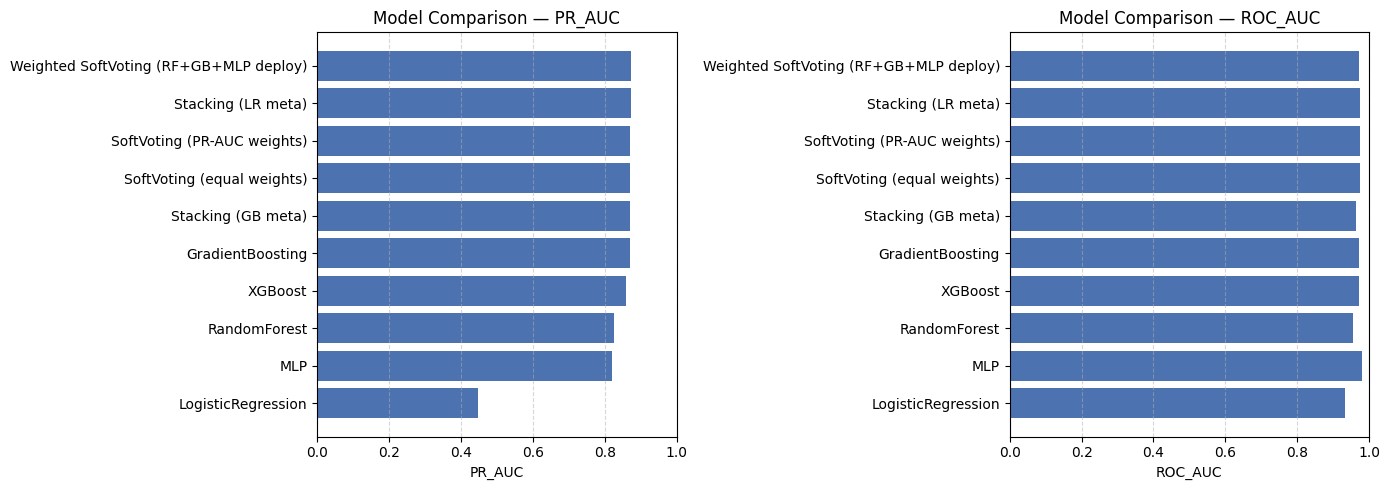

In [15]:
plot_df = results_df.sort_values("PR_AUC", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ["PR_AUC", "ROC_AUC"]):
    ax.barh(plot_df["model"], plot_df[metric], color="#4C72B0")
    ax.set_xlabel(metric)
    ax.set_title(f"Model Comparison — {metric}")
    ax.grid(True, axis="x", linestyle="--", alpha=0.5)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


## 13. Threshold Selection

A classification model outputs a **probability** between 0 and 1 for each machine.
To make a decision (failure / no failure) we need a cutoff point — the threshold.

**The default is 0.5** — flag anything the model is more than 50% confident about.
This works fine for balanced datasets. On ours (3.4% failure rate) it can miss failures
because the model rarely exceeds 0.5 for true failure cases.

**Our approach:** scan every possible threshold on the Precision–Recall curve and
find the one that achieves **recall ≥ 0.95** with the highest possible precision.

Why recall ≥ 0.95?

> In predictive maintenance, **missing a failure** (false negative) means unexpected
> downtime, equipment damage, and potential safety risk. A **false alarm** (false positive)
> only means an unnecessary inspection — far cheaper. So we deliberately sacrifice
> precision to maximise recall.

**Effect of calibration:**  
Isotonic calibration compresses safe-machine probabilities toward zero. This shifts
the tuned threshold from ~0.18 (uncalibrated Soft Voting) to ~0.02 (calibrated).
The **discrimination ability** (PR-AUC, ROC-AUC) is the same — only the probability
scale changes. The threshold is not hardcoded; `train.py` recalculates it automatically
from the PR curve each time the model is retrained.

The cells below show where the threshold comes from on the calibrated deployment model.


Tuned threshold: 0.022948  (recall >= 0.95)

=== Probability score statistics (calibrated model) ===
Safe machines    — median: 0.0014  p95: 0.0567  max: 0.9001
Failing machines — median: 0.8806  p25: 0.6153  min: 0.0009


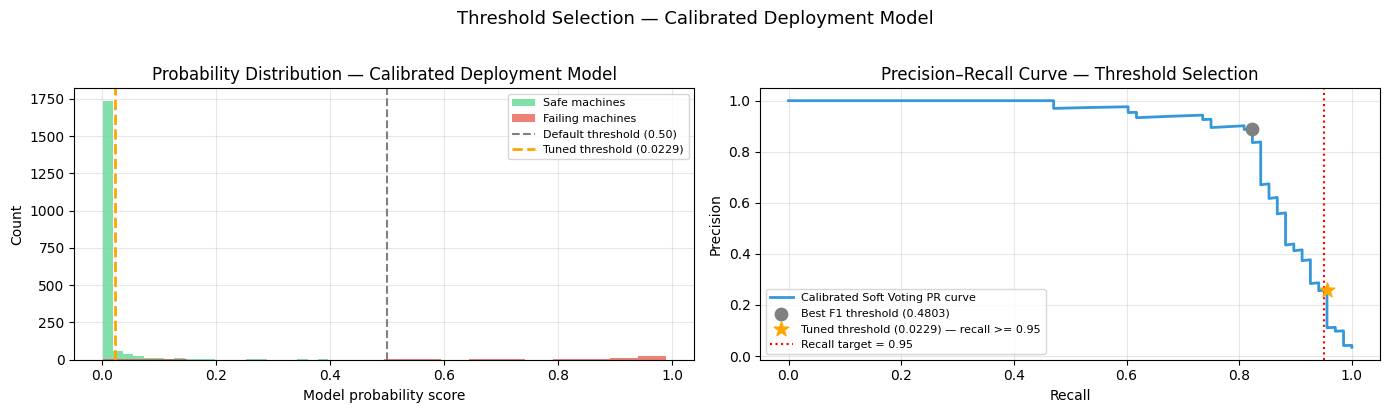

In [16]:
# Step 1: Get probabilities from the deployment model
deploy_row = next(r for r in results if r["model"] == "Weighted SoftVoting (RF+GB+MLP deploy)")
deploy_pipeline = deploy_row["pipeline"]

y_prob_deploy = deploy_pipeline.predict_proba(X_test)[:, 1]
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob_deploy)

# Step 2: Show raw probability distributions
safe_probs = y_prob_deploy[y_test.values == 0]
fail_probs = y_prob_deploy[y_test.values == 1]

# Find recall >= 0.95 threshold
RECALL_TARGET = 0.95
valid_idx = np.where(recall_vals[:-1] >= RECALL_TARGET)[0]
f1_scores  = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-10)
best_f1_idx = np.argmax(f1_scores)
tuned_idx = valid_idx[np.argmax(precision_vals[valid_idx])] if len(valid_idx) > 0 else best_f1_idx
tuned_threshold = float(thresholds[tuned_idx])

print(f"Tuned threshold: {tuned_threshold:.6f}  (recall >= {RECALL_TARGET})")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram of scores
axes[0].hist(safe_probs, bins=50, alpha=0.6, color="#2ecc71", label="Safe machines")
axes[0].hist(fail_probs, bins=20, alpha=0.7, color="#e74c3c", label="Failing machines")
axes[0].axvline(0.5,  color="grey",   linestyle="--", linewidth=1.5, label="Default threshold (0.50)")
axes[0].axvline(tuned_threshold, color="orange", linestyle="--", linewidth=2,
                label=f"Tuned threshold ({tuned_threshold:.4f})")
axes[0].set_xlabel("Model probability score")
axes[0].set_ylabel("Count")
axes[0].set_title("Probability Distribution — Calibrated Deployment Model")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

print("=== Probability score statistics (calibrated model) ===")
print(f"Safe machines    — median: {np.median(safe_probs):.4f}  p95: {np.percentile(safe_probs, 95):.4f}  max: {safe_probs.max():.4f}")
print(f"Failing machines — median: {np.median(fail_probs):.4f}  p25: {np.percentile(fail_probs, 25):.4f}  min: {fail_probs.min():.4f}")

# Right: PR curve with threshold marked
axes[1].plot(recall_vals, precision_vals, color="#3498db", linewidth=2, label="Calibrated Soft Voting PR curve")
axes[1].scatter(recall_vals[best_f1_idx], precision_vals[best_f1_idx],
                color="grey", zorder=5, s=80,
                label=f"Best F1 threshold ({thresholds[best_f1_idx]:.4f})")
axes[1].scatter(recall_vals[tuned_idx], precision_vals[tuned_idx],
                color="orange", zorder=6, s=120, marker="*",
                label=f"Tuned threshold ({tuned_threshold:.4f}) — recall >= {RECALL_TARGET}")
axes[1].axvline(RECALL_TARGET, color="red", linestyle=":", linewidth=1.5,
                label=f"Recall target = {RECALL_TARGET}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curve — Threshold Selection")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Threshold Selection — Calibrated Deployment Model", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Threshold comparison table — deployment ensemble with calibrated RF
print("=== What happens at different thresholds? (deployment ensemble with calibrated RF) ===")
print(f"{'Threshold':>10} | {'Recall':>8} | {'Precision':>10} | {'F1':>6} | {'False Alarms':>13} | {'Missed Failures':>16}")
print("-" * 75)

rows = []
for t in [0.01, 0.02, 0.05, 0.10, 0.20, 0.50, 0.70]:
    pred = (y_prob_deploy >= t).astype(int)
    tp = ((pred==1) & (y_test.values==1)).sum()
    fp = ((pred==1) & (y_test.values==0)).sum()
    fn = ((pred==0) & (y_test.values==1)).sum()
    recall    = tp / (tp + fn) if (tp+fn) > 0 else 0
    precision = tp / (tp + fp) if (tp+fp) > 0 else 0
    f1        = 2*recall*precision / (recall+precision) if (recall+precision) > 0 else 0
    note = ""
    if abs(t - tuned_threshold) < 0.01:
        note = " <- SELECTED"
    elif t == 0.50:
        note = " <- sklearn default"
    print(f"{t:>10.2f} | {recall:>8.3f} | {precision:>10.3f} | {f1:>6.3f} | {fp:>13} | {fn:>16}{note}")
    rows.append({"Threshold": t, "Recall": round(recall,3), "Precision": round(precision,3),
                 "F1": round(f1,3), "False Alarms": fp, "Missed Failures": fn})

print()
print(f"Total failures in test set: {y_test.sum()}")
print(f"Tuned threshold: {tuned_threshold:.6f}")
print()
print("Key insight:")
print(f"  RF isotonic calibration shifts part of the ensemble probability distribution,")
print(f"  especially for safe machines.")
print(f"  To achieve recall >= 0.95, the threshold must be set very low (~0.02).")
print(f"  This is expected — the discrimination remains strong, while the score scale changes.")


=== What happens at different thresholds? (calibrated model) ===
 Threshold |   Recall |  Precision |     F1 |  False Alarms |  Missed Failures
---------------------------------------------------------------------------
      0.01 |    0.956 |      0.210 |  0.345 |           244 |                3
      0.02 |    0.956 |      0.249 |  0.395 |           196 |                3 <- SELECTED
      0.05 |    0.926 |      0.362 |  0.521 |           111 |                5
      0.10 |    0.882 |      0.517 |  0.652 |            56 |                8
      0.20 |    0.838 |      0.713 |  0.770 |            23 |               11
      0.50 |    0.809 |      0.902 |  0.853 |             6 |               13 <- sklearn default
      0.70 |    0.706 |      0.941 |  0.807 |             3 |               20

Total failures in test set: 68
Tuned threshold: 0.022948

Key insight:
  Isotonic calibration compresses safe-machine probabilities toward zero.
  To achieve recall >= 0.95, the threshold must be

### What the Table Shows

Reading across the rows from top to bottom — as you raise the threshold:

- **Recall drops** — you start missing more real failures
- **Precision rises** — when you do flag something, you're more often right
- **False alarms drop** — fewer unnecessary inspections

The question is: **where do you draw the line?**

For predictive maintenance the answer is clear — stay as high up the table as possible
(high recall) while keeping false alarms at a manageable level.

**Probability-scale note:**  
Because the deployment ensemble includes a calibrated Random Forest and combines three
different probability-producing models, the final score distribution may differ from the
earlier experimental soft-voting versions. That is expected. The threshold is therefore
not hardcoded — it is recalculated from the Precision–Recall curve after training.

The threshold used in deployment is chosen to achieve the recall target while preserving
as much precision as possible.

## 14. Cross-Validation of Selected Model

A single train/test split (80/20) gives one performance estimate that depends on which
rows happened to land in the test set. To confirm the Soft Voting result is stable and
not an artifact of a fortunate split, we run **5-fold stratified cross-validation**.

Stratified folds are used because the dataset is heavily imbalanced (3.4% failure rate)
— regular KFold could produce folds with very few or zero failure rows.

Each fold trains on 80% and tests on 20%, rotating until every row has been tested once.
The final score is reported as **mean ± standard deviation** across all 5 folds.

In [ ]:
# Rebuild the deployment model for CV
# (matches the updated deployment configuration)

rf_cv = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

gb_cv = GradientBoostingClassifier(
    random_state=RANDOM_STATE
)

mlp_cv = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=RANDOM_STATE
)

rf_cv_cal = CalibratedClassifierCV(rf_cv, method="isotonic", cv=3)

cv_voting = VotingClassifier(
    estimators=[
        ("rf", rf_cv_cal),
        ("gb", gb_cv),
        ("mlp", mlp_cv),
    ],
    voting="soft",
    weights=[2, 2, 1],
)

cv_pipeline = Pipeline([
    ("preprocess", preprocess),
    ("clf", cv_voting),
])

# 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
}

print("Running 5-fold stratified cross-validation (deployment model: RF + GB + MLP)...")
cv_scores = cross_validate(
    cv_pipeline,
    X,
    y,
    cv=skf,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

pr_scores = cv_scores["test_pr_auc"]
roc_scores = cv_scores["test_roc_auc"]

print("\n=== 5-Fold Cross-Validation — Deployment Soft Voting (RF + GB + MLP) ===")
print(f"{'Fold':<8} {'PR-AUC':>10} {'ROC-AUC':>10}")
print("-" * 30)
for i, (pr, roc) in enumerate(zip(pr_scores, roc_scores), 1):
    print(f"Fold {i:<3} {pr:>10.4f} {roc:>10.4f}")
print("-" * 30)
print(f"{'Mean':<8} {pr_scores.mean():>10.4f} {roc_scores.mean():>10.4f}")
print(f"{'Std':<8} {pr_scores.std():>10.4f} {roc_scores.std():>10.4f}")
print()
print(f"PR-AUC:  {pr_scores.mean():.4f} +/- {pr_scores.std():.4f}")
print(f"ROC-AUC: {roc_scores.mean():.4f} +/- {roc_scores.std():.4f}")
print()
print("The low fold-to-fold variation, especially in ROC-AUC, suggests that the deployment ensemble is stable across data splits.")

Running 5-fold stratified cross-validation (deployment model: RF + GB + MLP)...

=== 5-Fold Cross-Validation — Deployment Soft Voting (RF + GB + MLP) ===
Fold         PR-AUC    ROC-AUC
------------------------------
Fold 1       0.8641     0.9783
Fold 2       0.8808     0.9801
Fold 3       0.7856     0.9790
Fold 4       0.8632     0.9741
Fold 5       0.8477     0.9724
------------------------------
Mean         0.8483     0.9768
Std          0.0330     0.0030

PR-AUC:  0.8483 +/- 0.0330
ROC-AUC: 0.9768 +/- 0.0030

Low standard deviation confirms the deployment ensemble is stable across data splits.


## 15. Conclusion

The table above shows the full comparison across individual classifiers,
deep learning models, and ensemble strategies.

**Selection rationale:**
- Primary criterion: highest **PR-AUC** (most informative metric for imbalanced failure detection)
- Secondary: **Recall** at the selected operating threshold
- Practical: probability scores should support dashboard interpretation and risk ranking

**Key observations:**
- Ensemble methods (Soft Voting, Stacking) consistently outperform individual models
- Deep learning models do not clearly outperform strong ensemble methods on this
  structured tabular dataset
- This supports H3: ensemble models achieve superior precision–recall performance
  compared to most single-model alternatives

The selected deployment model is a **Soft Voting ensemble of Random Forest,
Gradient Boosting, and MLP**, with Random Forest calibrated and voting weights
set to favour the stronger tree-based learners. This configuration provides a
good balance between predictive performance, probability usability, and
deployment simplicity for the dashboard.